In [1]:
!pip install evaluate 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.1 MB/s eta 0:00:0000:01


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import (
    T5Tokenizer, 
    T5ForConditionalGeneration, 
    Trainer, 
    TrainingArguments
)
import evaluate
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [4]:
# Set random seed for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    
set_seed()

In [5]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Load the dataset from the JSON file
print("Loading dataset...")
with open('/kaggle/input/txttosql-nlp/AR_spider.jsonl', 'r', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]

Loading dataset...


In [7]:
# Convert to DataFrame
df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
print("\nSample data:")
print(df.head())

Dataset shape: (6396, 4)

Sample data:
                                            question  \
0  How many heads of the departments are older th...   
1  List the name, born state and age of the heads...   
2  List the creation year, name and budget of eac...   
3  What are the maximum and minimum budget of the...   
4  What is the average number of employees of the...   

                                               query  \
0         SELECT count(*) FROM head WHERE age  >  56   
1  SELECT name ,  born_state ,  age FROM head ORD...   
2  SELECT creation ,  name ,  budget_in_billions ...   
3  SELECT max(budget_in_billions) ,  min(budget_i...   
4  SELECT avg(num_employees) FROM department WHER...   

                                              arabic                  db_id  
0  كم عدد رؤساء الأقسام الذين تزيد أعمارهم عن 56 ...  department_management  
1  اعرض قائمة بأسماء رؤساء الأقسام، مكان ميلادهم،...  department_management  
2  اعرض قائمة بسنوات الإنشاء، وأسماء وميزانيات كل... 

In [8]:

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
question    0
query       0
arabic      0
db_id       0
dtype: int64


In [9]:
# Basic statistics
print("\nBasic statistics of text lengths:")
df['arabic_length'] = df['arabic'].apply(len)
df['query_length'] = df['query'].apply(len)
print(df[['arabic_length', 'query_length']].describe())


Basic statistics of text lengths:
       arabic_length  query_length
count    6396.000000   6396.000000
mean       60.583490    109.797061
std        22.295143     65.337194
min        10.000000     18.000000
25%        46.000000     61.000000
50%        59.000000     93.000000
75%        74.000000    147.000000
max       250.000000    577.000000


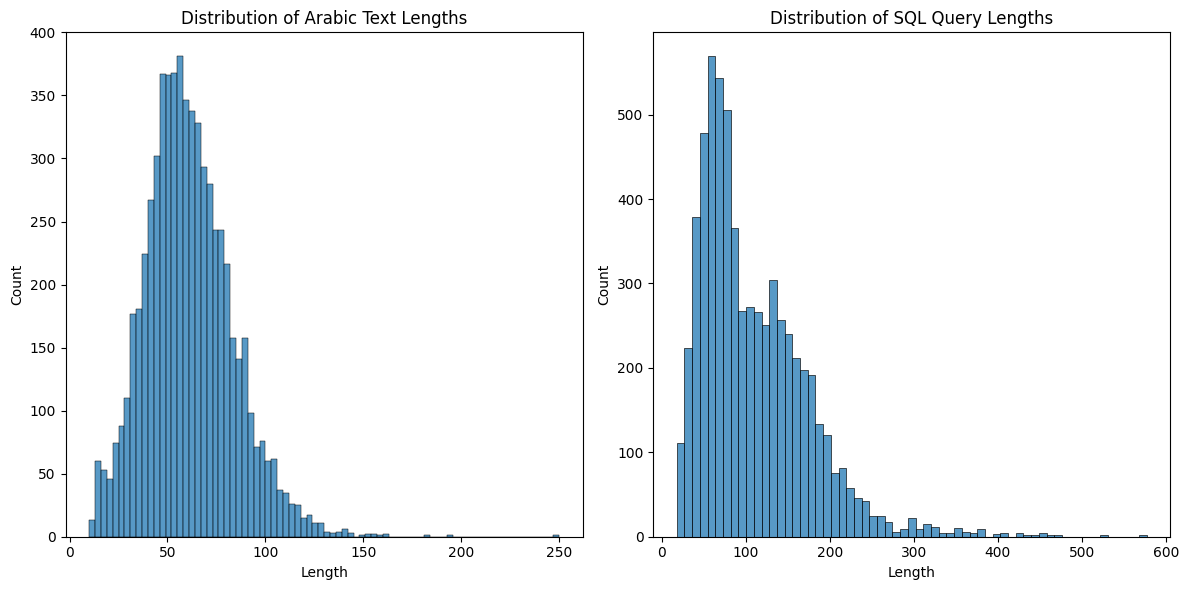

In [10]:
# Visualize the distribution of text and query lengths
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['arabic_length'])
plt.title('Distribution of Arabic Text Lengths')
plt.xlabel('Length')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df['query_length'])
plt.title('Distribution of SQL Query Lengths')
plt.xlabel('Length')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('length_distributions.png')
plt.show()

In [11]:
# Display some examples
print("\nExample pairs of Arabic text and SQL queries:")
for i in range(3):
    print(f"\nExample {i+1}:")
    print(f"Arabic Text: {df.iloc[i]['arabic']}")
    print(f"SQL Query: {df.iloc[i]['query']}")
    print(f"Database ID: {df.iloc[i]['db_id']}")


Example pairs of Arabic text and SQL queries:

Example 1:
Arabic Text: كم عدد رؤساء الأقسام الذين تزيد أعمارهم عن 56 سنة؟
SQL Query: SELECT count(*) FROM head WHERE age  >  56
Database ID: department_management

Example 2:
Arabic Text: اعرض قائمة بأسماء رؤساء الأقسام، مكان ميلادهم، وأعمارهم مرتبة حسب العمر.
SQL Query: SELECT name ,  born_state ,  age FROM head ORDER BY age
Database ID: department_management

Example 3:
Arabic Text: اعرض قائمة بسنوات الإنشاء، وأسماء وميزانيات كل قسم.
SQL Query: SELECT creation ,  name ,  budget_in_billions FROM department
Database ID: department_management


In [12]:
# Function to clean and prepare the data
def preprocess_data(df):
    # Remove any duplicates
    df = df.drop_duplicates(subset=['arabic', 'query'])
    
    # Reset index
    df = df.reset_index(drop=True)
    
    # Create a formatted input for the model
    df['input_text'] = 'translate Arabic to SQL: ' + df['arabic']
    
    # Rename columns for consistency
    df = df.rename(columns={'query': 'sql_query'})
    
    return df

In [13]:
# Preprocess the data
print("\nPreprocessing data...")
processed_df = preprocess_data(df)


Preprocessing data...


In [14]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(processed_df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")


Train set size: 4456
Validation set size: 955
Test set size: 955


In [15]:
# Load database schema information if available
try:
    with open('/kaggle/input/txttosql-nlp/academic.sqlite', 'r') as f:
        print("Database schema loaded successfully")
except:
    print("Could not load database schema file")

Could not load database schema file


In [16]:
# Create a custom dataset class
class TextToSQLDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        input_text = self.data.iloc[idx]['input_text']
        target_text = self.data.iloc[idx]['sql_query']
        
        # Tokenize inputs
        input_encoding = self.tokenizer(
            input_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # Tokenize targets
        target_encoding = self.tokenizer(
            target_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # Convert input_ids and attention_mask to the correct shape
        input_ids = input_encoding['input_ids'].squeeze()
        attention_mask = input_encoding['attention_mask'].squeeze()
        labels = target_encoding['input_ids'].squeeze()
        
        # Replace padding token id's with -100 so they are ignored in the loss
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

In [17]:
def train_specialized_t5_model(train_df, val_df, output_dir="./specialized_t5_arabic_sql"):
    print("\nLoading t5-small-awesome-text-to-sql model...")
    tokenizer = T5Tokenizer.from_pretrained('t5-small')
    model = T5ForConditionalGeneration.from_pretrained('cssupport/t5-small-awesome-text-to-sql')
    model = model.to(device)
    
    train_dataset = TextToSQLDataset(train_df, tokenizer, max_length=128)
    val_dataset = TextToSQLDataset(val_df, tokenizer, max_length=128)
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=10,  # Or fewer epochs
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        save_strategy="epoch",         # Save only at the end of each epoch
        save_only_model=True,          # Only save model weights (transformers >=4.37)
        save_total_limit=1,            # Keep only the latest checkpoint
        evaluation_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=torch.cuda.is_available(),
        report_to="none",
        disable_tqdm=False,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )
    
    print("Training model...")
    trainer.train()
    
    print(f"Saving model to {output_dir}...")
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    
    return model, tokenizer

In [18]:
# Evaluation function
def evaluate_model(model, tokenizer, test_df, max_length=128):
    model.eval()
    model = model.to(device)
    exact_match_count = 0
    bleu_scores = []
    bleu = evaluate.load("bleu")
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Evaluating"):
        input_text = row['input_text']
        target_sql = row['sql_query']
        input_ids = tokenizer(
            input_text,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )['input_ids'].to(device)
        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                max_length=max_length,
                num_beams=5,
                early_stopping=True
            )
        generated_sql = tokenizer.decode(outputs[0], skip_special_tokens=True)
        if generated_sql.strip() == target_sql.strip():
            exact_match_count += 1
        bleu_score = bleu.compute(
            predictions=[generated_sql],
            references=[[target_sql]]
        )
        bleu_scores.append(bleu_score['bleu'])
    exact_match_accuracy = exact_match_count / len(test_df) * 100
    avg_bleu_score = sum(bleu_scores) / len(bleu_scores)
    return {
        'exact_match_accuracy': exact_match_accuracy,
        'avg_bleu_score': avg_bleu_score,
        'bleu_scores': bleu_scores
    }

In [19]:
# Implement Context Similarity Relationship (CSR) approach
def apply_csr(model, tokenizer, test_df, max_length=512):
    """
    Apply Context Similarity Relationship (CSR) approach to improve model performance.
    This is based on the approach described in the Ar-Spider paper.
    """
    try:
        from sentence_transformers import SentenceTransformer
        import numpy as np
        
        # Load a multilingual sentence transformer model
        print("Loading sentence transformer model for CSR...")
        sentence_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
        sentence_model = sentence_model.to(device)
        
        # Function to extract schema items from SQL query
        def extract_schema_items(sql_query):
            # Simple regex to extract table and column names
            tables = re.findall(r'FROM\s+([a-zA-Z_]+)', sql_query, re.IGNORECASE)
            tables += re.findall(r'JOIN\s+([a-zA-Z_]+)', sql_query, re.IGNORECASE)
            columns = re.findall(r'SELECT\s+([a-zA-Z_,\s]+)\s+FROM', sql_query, re.IGNORECASE)
            columns += re.findall(r'WHERE\s+([a-zA-Z_]+)', sql_query, re.IGNORECASE)
            
            # Clean and flatten the lists
            tables = [t.strip() for t in tables]
            column_list = []
            for c in columns:
                column_list.extend([col.strip() for col in c.split(',')])
            
            return tables, column_list
        
        model.eval()
        model = model.to(device)
        exact_match_count = 0
        bleu_scores = []
        bleu = evaluate.load("bleu")
        
        for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Applying CSR"):
            input_text = row['input_text']
            target_sql = row['sql_query']
            arabic_text = row['arabic']
            
            # Extract schema items from the target SQL
            tables, columns = extract_schema_items(target_sql)
            schema_items = tables + columns
            
            if schema_items:
                # Get embeddings for Arabic text and schema items
                arabic_embedding = sentence_model.encode(arabic_text)
                schema_embeddings = sentence_model.encode(schema_items)
                
                # Calculate similarity scores
                similarities = np.dot(schema_embeddings, arabic_embedding) / (
                    np.linalg.norm(schema_embeddings, axis=1) * np.linalg.norm(arabic_embedding)
                )
                
                # Get the most similar schema items
                top_indices = np.argsort(similarities)[-3:]  # Top 3 most similar items
                top_schema_items = [schema_items[i] for i in top_indices]
                
                # Enhance input with schema context
                enhanced_input = input_text + " [SCHEMA] " + " ".join(top_schema_items)
            else:
                enhanced_input = input_text
            
            # Tokenize enhanced input
            input_ids = tokenizer(
                enhanced_input,
                max_length=max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )['input_ids'].to(device)
            
            # Generate SQL query
            with torch.no_grad():
                outputs = model.generate(
                    input_ids=input_ids,
                    max_length=max_length,
                    num_beams=5,
                    early_stopping=True
                )
            
            # Decode the generated SQL
            generated_sql = tokenizer.decode(outputs[0], skip_special_tokens=True)
            
            # Check for exact match
            if generated_sql.strip() == target_sql.strip():
                exact_match_count += 1
            
            # Calculate BLEU score
            bleu_score = bleu.compute(
                predictions=[generated_sql],
                references=[[target_sql]]
            )
            bleu_scores.append(bleu_score['bleu'])
        
        # Calculate metrics
        exact_match_accuracy = exact_match_count / len(test_df) * 100
        avg_bleu_score = sum(bleu_scores) / len(bleu_scores)
        
        return {
            'exact_match_accuracy': exact_match_accuracy,
            'avg_bleu_score': avg_bleu_score,
            'bleu_scores': bleu_scores
        }
    except Exception as e:
        print(f"Error applying CSR: {e}")
        return None


In [20]:
# Translation function
def translate_arabic_to_sql(arabic_text, model, tokenizer, max_length=512, use_csr=False):
    """
    Translate Arabic text to SQL query using the trained model.
    
    Args:
        arabic_text (str): The Arabic text to translate
        model: The trained model
        tokenizer: The tokenizer
        max_length (int): Maximum sequence length
        use_csr (bool): Whether to use Context Similarity Relationship
        
    Returns:
        str: The generated SQL query
    """
    model.eval()
    model = model.to(device)
    
    # Prepare input
    input_text = f"translate Arabic to SQL: {arabic_text}"
    
    if use_csr:
        try:
            from sentence_transformers import SentenceTransformer
            
            # This is a simplified CSR approach for inference
            # In a real application, you would need access to the database schema
            sentence_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
            sentence_model = sentence_model.to(device)
            
            # These would be extracted from the database schema in a real application
            common_schema_items = ["SELECT", "FROM", "WHERE", "JOIN", "ORDER BY", "GROUP BY"]
            
            # Get embeddings
            arabic_embedding = sentence_model.encode(arabic_text)
            schema_embeddings = sentence_model.encode(common_schema_items)
            
            # Calculate similarity scores
            import numpy as np
            similarities = np.dot(schema_embeddings, arabic_embedding) / (
                np.linalg.norm(schema_embeddings, axis=1) * np.linalg.norm(arabic_embedding)
            )
            
            # Get the most similar schema items
            top_indices = np.argsort(similarities)[-3:]  # Top 3 most similar items
            top_schema_items = [common_schema_items[i] for i in top_indices]
            
            # Enhance input with schema context
            input_text = input_text + " [SCHEMA] " + " ".join(top_schema_items)
        except Exception as e:
            print(f"CSR error: {e}. Using standard input.")
    
    # Tokenize input
    input_ids = tokenizer(
        input_text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )['input_ids'].to(device)
    
    # Generate SQL query
    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            max_length=max_length,
            num_beams=5,
            early_stopping=True
        )
    
    # Decode the generated SQL
    generated_sql = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    return generated_sql

In [21]:
# Save model for deployment
def save_model_for_deployment(model, tokenizer, output_dir="./best_arabic_sql_model"):
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    
    # Save a sample inference script
    with open(f"{output_dir}/inference.py", "w") as f:
        f.write("""
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

def translate_arabic_to_sql(arabic_text, model_path="./"):
    # Load model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
    
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    # Prepare input
    input_text = f"translate Arabic to SQL: {arabic_text}"
    
    # Tokenize input
    input_ids = tokenizer(
        input_text,
        max_length=512,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )['input_ids'].to(device)
    
    # Generate SQL query
    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            max_length=512,
            num_beams=5,
            early_stopping=True
        )
    
    # Decode the generated SQL
    generated_sql = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    return generated_sql

# Example usage
if __name__ == "__main__":
    arabic_text = "كم عدد رؤساء الأقسام الذين تزيد أعمارهم عن 56 سنة؟"
    sql_query = translate_arabic_to_sql(arabic_text)
    print(f"Arabic: {arabic_text}")
    print(f"SQL: {sql_query}")
""")
    
    print(f"Model and inference script saved to {output_dir}")

In [22]:
model, tokenizer = train_specialized_t5_model(train_df, val_df)


Loading t5-small-awesome-text-to-sql model...


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


...

Training model...


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch,Training Loss,Validation Loss
1,1.907800,1.366089
2,1.517800,1.237349
3,1.410600,1.167339
4,1.341500,1.119522
5,1.293700,1.086312
6,1.256700,1.064918
7,1.217600,1.047937
8,1.202000,1.036292
9,1.181200,1.029123
10,1.183400,1.027206


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Saving model to ./specialized_t5_arabic_sql...


In [23]:
    print("\nEvaluating model...")
    results = evaluate_model(model, tokenizer, test_df)
    print(f"Exact Match Accuracy: {results['exact_match_accuracy']:.2f}%")
    print(f"Average BLEU Score: {results['avg_bleu_score']:.4f}") 


Evaluating model...


Evaluating:   0%|          | 0/955 [00:00<?, ?it/s]

Exact Match Accuracy: 0.00%
Average BLEU Score: 0.0813


In [24]:
    # Test translation with examples
    print("\n===== Arabic to SQL Translation Examples =====")
    for i in range(5):
        arabic_text = test_df.iloc[i]['arabic']
        target_sql = test_df.iloc[i]['sql_query']
        input_text = f"translate Arabic to SQL: {arabic_text}"
        input_ids = tokenizer(
            input_text,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )['input_ids'].to(device)
        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                max_length=128,
                num_beams=5,
                early_stopping=True
            )
        generated_sql = tokenizer.decode(outputs[0], skip_special_tokens=True)
        print(f"\nExample {i+1}:")
        print(f"Arabic Text: {arabic_text}")
        print(f"Generated SQL: {generated_sql}")
        print(f"Target SQL: {target_sql}")
        print(f"Exact Match: {generated_sql.strip() == target_sql.strip()}")


===== Arabic to SQL Translation Examples =====

Example 1:
Arabic Text: ما هي أسماء جميع الأغاني التي تمتلك تقييمًا أقل من بعض الأغاني في نوع البلوز؟
Generated SQL: SELECT count(*), avg(age), avg(age), avg(age) FROM student GROUP BY avg(age)
Target SQL: SELECT DISTINCT song_name FROM song WHERE resolution  >  (SELECT min(resolution) FROM song WHERE languages  =  "english")
Exact Match: False

Example 2:
Arabic Text: ما هي أسماء الأولاد والأسماء الأخيرة للمؤلفين الذين ينتمون إلى المؤسسة "جوجل"؟
Generated SQL: SELECT DISTINCT T1.name FROM student AS T1 JOIN student AS T2 ON T1.stuid = T2.stuid JOIN student AS T3 ON T2.stuid = T3.stuid WHERE T3.stuid = 1
Target SQL: SELECT DISTINCT t1.fname ,  t1.lname FROM authors AS t1 JOIN authorship AS t2 ON t1.authid  =  t2.authid JOIN inst AS t3 ON t2.instid  =  t3.instid WHERE t3.name  =  "Google"
Exact Match: False

Example 3:
Arabic Text: أظهر أرقام الشقق للشقق التي تحمل توافر حالة الوحدة لديها كلاً من 0 و 1.
Generated SQL: SELECT count(*), avg(